%pip install numpy pandas librosa torch torchaudio matplotlib seaborn tqdm ipywidgets scikit-learn

%pip uninstall -y torch torchvision torchaudio
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import torchaudio
import warnings
import logging
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from datetime import datetime
import json
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from pathlib import Path

In [2]:
os.environ["DATASET_DIR"] = "/datasets/kaspoas"


In [21]:
BATCH_SIZE = 64
LR = 1e-3
MAX_EPOCHS = 100
PATIENCE = 5 #stops after 5 epcohs with no improvement
MIN_DELTA = 1e-3 #min improvement required
SPEC_AUG = False

RUN_NAME = "crnn_lr_5e-3"

In [22]:
# Pick which cleaned FMA subset to train on. 
SUBSET = "small"  # or "medium"
if SUBSET not in {"small", "medium"}:
    raise ValueError("SUBSET must be either 'small' or 'medium'.")

# Resolve paths from either the project root or the code/ subdirectory.
PROJECT_CANDIDATES = [Path.cwd(), Path.cwd().parent]

if "DATASET_DIR" in os.environ:
    PROJECT_CANDIDATES.append(Path(os.environ["DATASET_DIR"]))
    
for candidate in PROJECT_CANDIDATES:
    preprocessed_path = candidate / "fma_preprocessed"
    if features_path.exists() and preprocessed_path.exists():
        PROJECT_DIR = candidate.resolve()
        PREPROCESSED_DIR = preprocessed_path.resolve()
        break
else:
    raise FileNotFoundError("Could not find fma_metadata/features.csv and fma_preprocessed/.")

# Files written by data_preprocessing.ipynb.
TRAIN_SPEC_PATH = PREPROCESSED_DIR / "spectrograms_manifest_training.csv"
VAL_SPEC_PATH   = PREPROCESSED_DIR / "spectrograms_manifest_validation.csv"
TEST_SPEC_PATH  = PREPROCESSED_DIR / "spectrograms_manifest_test.csv"
GENRE_MAP_PATH = PREPROCESSED_DIR / f"genre_to_idx_{SUBSET}.csv"

print({
    "SUBSET": SUBSET,
    "PROJECT_DIR": str(PROJECT_DIR),
    "TRAIN_SPEC_DIR": str(TRAIN_SPEC_DIR),
    "PREPROCESSED_DIR": str(PREPROCESSED_DIR),
    "GENRE_MAP_PATH": str(GENRE_MAP_PATH),
})



{'SUBSET': 'small', 'PROJECT_DIR': '/datasets/kaspoas', 'FEATURES_DIR': '/datasets/kaspoas/fma_metadata/features.csv', 'PREPROCESSED_DIR': '/datasets/kaspoas/fma_preprocessed', 'SPECTROGRAM_PATH': '/datasets/kaspoas/fma_preprocessed/spectrograms_manifest.csv', 'GENRE_MAP_PATH': '/datasets/kaspoas/fma_preprocessed/genre_to_idx_small.csv'}


In [23]:
# Data loading from data_preprocessing.ipynb spectrogram outputs

def load_data(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Could not find {path}.\nRun data_preprocessing.ipynb first.")

    df = pd.read_csv(path)
    df = df.copy()
    df["track_id"] = df["track_id"].astype(int)
    df["label"] = df["label"].astype(int)

    # Convert saved paths into Path objects
    df["spectrogram_path"] = df["spectrogram_path"].apply(Path)

    return df


class SpecDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, augment: bool = False):
        self.frame = frame.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.frame)

    def spec_augment(self, spec):
        # spec shape: (1, n_mels, time)
        _, n_mels, n_frames = spec.shape

        # Light frequency mask
        f = np.random.randint(0, 5)
        if f > 0:
            f0 = np.random.randint(0, max(1, n_mels - f))
            spec[:, f0:f0 + f, :] = 0

        # Light time mask
        t = np.random.randint(0, 40)
        if t > 0:
            t0 = np.random.randint(0, max(1, n_frames - t))
            spec[:, :, t0:t0 + t] = 0

        return spec

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]

        spec = np.load(row["spectrogram_path"]).astype(np.float32)

        # Ensure shape is (channels, n_mels, time)
        if spec.ndim == 2:
            spec = spec[None, :, :]

        if self.augment:
            spec = self.spec_augment(spec)

        label = int(row["label"])

        return torch.from_numpy(spec), torch.tensor(label, dtype=torch.long)



## Load Data

In [24]:

# device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpus = torch.cuda.device_count()
print(f"Using device: {device}  ({n_gpus} GPU(s))")

# load preprocessed spectrograms
print("Loading preprocessed FMA spectrograms...")

train_df = load_data(TRAIN_SPEC_PATH)
val_df   = load_data(VAL_SPEC_PATH)
test_df  = load_data(TEST_SPEC_PATH)

classes = (train_df[["label", "genre"]].drop_duplicates().sort_values("label")["genre"].tolist())

NUM_CLASSES = len(classes)

print(f"Classes found: {NUM_CLASSES} -> {classes}")
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")


# get spectrogram dimensions from one file
sample_spec = np.load(train_df.iloc[0]["spectrogram_path"])

if sample_spec.ndim == 2:
    N_MELS, MAX_FRAMES = sample_spec.shape
elif sample_spec.ndim == 3:
    N_MELS, MAX_FRAMES = sample_spec.shape[-2], sample_spec.shape[-1]
else:
    raise ValueError(f"Expected 2D or 3D spectrogram, got shape {sample_spec.shape}")
    
print(f"Spectrogram shape: n_mels={N_MELS}, frames={MAX_FRAMES}")


# data loaders
num_workers = min(4 * max(n_gpus, 1), 4)
pin         = device.type == "cuda"

train_loader = DataLoader(SpecDataset(train_df, augment=SPEC_AUG), batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=num_workers, pin_memory=pin,
                          persistent_workers=num_workers > 0)
val_loader   = DataLoader(SpecDataset(val_df),   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=num_workers, pin_memory=pin,
                          persistent_workers=num_workers > 0)
test_loader  = DataLoader(SpecDataset(test_df),  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=num_workers, pin_memory=pin,
                          persistent_workers=num_workers > 0)

Using device: cuda  (2 GPU(s))
Loading preprocessed FMA spectrograms...
Classes found: 8 -> ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']
Train: 6394  Val: 800  Test: 800
Spectrogram shape: n_mels=64, frames=1001


### Model

In [25]:
class ConvBlock(nn.Module):
    #Conv2D -> BatchNorm -> ReLU -> MaxPool block
    def __init__(self, in_ch, out_ch, pool=(2, 2)):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(pool),
            nn.Dropout2d(0.2),
        )

    def forward(self, x):
        return self.block(x)


class CRNN(nn.Module):
    def __init__(self, lstm_hidden=128, lstm_layers=2, dropout=0.3):
        super().__init__()

        self.cnn = nn.Sequential(
            ConvBlock(1,   16, pool=(2, 2)),
            ConvBlock(16,  32, pool=(2, 2)),
            ConvBlock(32, 64, pool=(4, 1)),
        )

        self.freq_out = N_MELS // (2 * 2 * 4)
        self.lstm_in  = 64 * self.freq_out

        self.lstm = nn.LSTM(
            input_size=self.lstm_in,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden * 2, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, NUM_CLASSES),
        )

    def forward(self, x):
        x = self.cnn(x)
        B, C, F, T = x.shape
        x = x.permute(0, 3, 1, 2).reshape(B, T, C * F)
        x, _ = self.lstm(x)
        #x = x.mean(dim=1)
        #return self.classifier(x)
        return self.classifier(x[:, -1, :])


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for specs, labels in tqdm(loader, desc="  Train", leave=False, unit="batch"):
        specs, labels = specs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(specs)
        loss    = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        preds       = outputs.detach().argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for specs, labels in tqdm(loader, desc="  Eval ", leave=False, unit="batch"):
        specs, labels = specs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs    = model(specs)
        loss       = criterion(outputs, labels)
        total_loss += loss.item() * labels.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


## Results Functions

In [26]:
def make_results_dir(run_name):
    results_dir = Path("results") / run_name
    results_dir.mkdir(parents=True, exist_ok=True)
    return results_dir


def save_results(run_name, history, test_loss, test_acc, y_true, y_pred, class_names, best_model_path):
    results_dir = make_results_dir(run_name)
    history_df = pd.DataFrame(history)

    # Save per-epoch training history
    history_df.to_csv(results_dir / "training_history.csv", index=False)

    # Accuracy curve
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
    plt.plot(history_df["epoch"], history_df["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(results_dir / "accuracy_curve.png", dpi=300)
    plt.show()

    # Loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(results_dir / "loss_curve.png", dpi=300)
    plt.show()

    # Classification report
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True
    )

    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(results_dir / "classification_report.csv")

    # Confusion matrix image
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    disp.plot(ax=ax, xticks_rotation=45, values_format="d")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig(results_dir / "confusion_matrix.png", dpi=300)
    plt.show()

    # Shared comparison file
    summary_row = {
        "run_name": run_name,
        "best_train_accuracy": history_df["train_acc"].max(),
        "best_validation_accuracy": history_df["val_acc"].max(),
        "test_accuracy": test_acc,
        "weighted_f1": report["weighted avg"]["f1-score"],
        "macro_f1": report["macro avg"]["f1-score"],
        "test_loss": test_loss,
        "best_validation_loss": history_df["val_loss"].min(),
        "epochs_completed": len(history_df),
        "batch_size": BATCH_SIZE,
        "learning_rate": LR
    }

    comparison_path = Path("results") / "comparison_summary.csv"

    pd.DataFrame([summary_row]).to_csv(
        comparison_path,
        mode="a" if comparison_path.exists() else "w",
        header=not comparison_path.exists(),
        index=False
    )

    print(f"Saved results to: {results_dir}")
    print(f"Updated comparison file: {comparison_path}")
    print(f"Best model saved at: {best_model_path}")

### Main

Run name: crnn_lr_5e-3
Saving results to: results/crnn_lr_5e-3
Using device: cuda  (2 GPU(s))

Model parameters: 831,016
DataParallel(
  (module): CRNN(
    (cnn): Sequential(
      (0): ConvBlock(
        (block): Sequential(
          (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
          (4): Dropout2d(p=0.2, inplace=False)
        )
      )
      (1): ConvBlock(
        (block): Sequential(
          (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
          (4): Dropout2d(p=0.2, inplac

  Train:   0%|          | 0/100 [00:00<?, ?batch/s]

  Eval :   0%|          | 0/13 [00:00<?, ?batch/s]

Train:      loss=2.0671  acc=0.1553
Validation: loss=2.0017  acc=0.2000
  -> best model saved (val acc=0.2000)

Epoch 2/100


  Train:   0%|          | 0/100 [00:00<?, ?batch/s]

...

  Eval :   0%|          | 0/13 [00:00<?, ?batch/s]

Train:      loss=1.2910  acc=0.5508
Validation: loss=1.3570  acc=0.5188
Coverged on validation loss


/tmp/ipykernel_3522765/1119579398.py:71: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  base.load_state_dict(torch.load(best_model_path, map_location=device))


  Eval :   0%|          | 0/13 [00:00<?, ?batch/s]


Test loss=1.6352  acc=0.4163

Classification Report:
               precision    recall  f1-score   support

   Electronic       0.54      0.57      0.56       100
 Experimental       0.17      0.21      0.19       100
         Folk       0.19      0.17      0.18       100
      Hip-Hop       0.64      0.70      0.67       100
 Instrumental       0.35      0.38      0.37       100
International       0.45      0.63      0.53       100
          Pop       0.32      0.19      0.24       100
         Rock       0.70      0.48      0.57       100

     accuracy                           0.42       800
    macro avg       0.42      0.42      0.41       800
 weighted avg       0.42      0.42      0.41       800



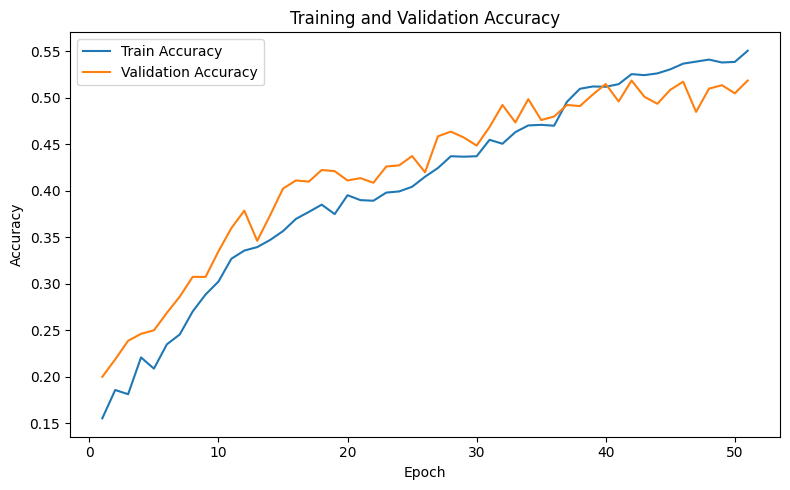

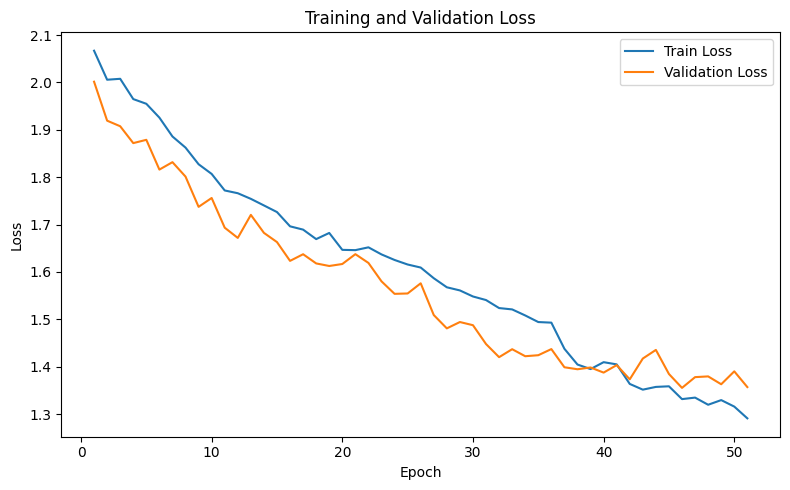

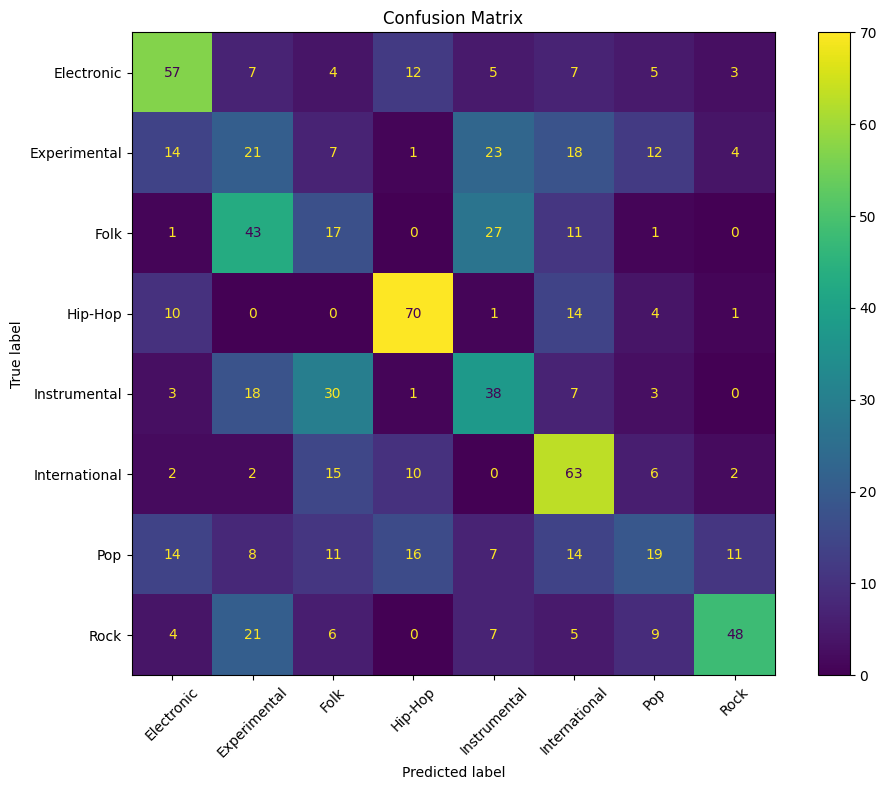

Saved results to: results/crnn_lr_5e-3
Updated comparison file: results/comparison_summary.csv
Best model saved at: results/crnn_lr_5e-3/best_crnn.pth


In [27]:

# results folder
results_dir = make_results_dir(RUN_NAME)
best_model_path = results_dir / "best_crnn.pth"

print(f"Run name: {RUN_NAME}")
print(f"Saving results to: {results_dir}")

# device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpus = torch.cuda.device_count()
print(f"Using device: {device}  ({n_gpus} GPU(s))")


# model
model = CRNN()
if device.type == "cuda" and torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6)

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")
print(model)

# training loop
best_acc = 0.0
best_loss = float("inf")
stagnant_epochs = 0
history = []

for epoch in range(1, MAX_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{MAX_EPOCHS}")
    train_loss, train_acc       = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_acc,  _, _  = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    print(f"Train:      loss={train_loss:.4f}  acc={train_acc:.4f}")
    print(f"Validation: loss={val_loss:.4f}  acc={val_acc:.4f}")

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "learning_rate": optimizer.param_groups[0]["lr"]
    })

    if val_acc > best_acc:
            best_acc = val_acc
            state = (model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict())
            torch.save(state, best_model_path)
            print(f"  -> best model saved (val acc={best_acc:.4f})")
    
    if val_loss > best_loss - MIN_DELTA:
        stagnant_epochs += 1

        if stagnant_epochs >= PATIENCE:
            print("Coverged on validation loss")
            break
    else:
        best_loss = val_loss
        stagnant_epochs = 0
        
        

# evaluation
base = model.module if isinstance(model, nn.DataParallel) else model
base.load_state_dict(torch.load(best_model_path, map_location=device))

test_loss, test_acc, test_preds, test_labels_out = evaluate(model, test_loader, criterion, device)
print(f"\nTest loss={test_loss:.4f}  acc={test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(test_labels_out, test_preds, target_names=class_names))

save_results(run_name=RUN_NAME, history=history, test_loss=test_loss, test_acc=test_acc, y_true=test_labels_out,
    y_pred=test_preds, class_names=class_names, best_model_path=best_model_path)

